In [119]:
import pandas as pd
df1 = pd.read_excel('_h_batch_process_data.xlsx')
df2 = pd.read_excel('_h_batch_production_data.xlsx')


In [120]:
augmented_data = pd.read_csv('synthetic_process_data.csv')
augmented_data = augmented_data.loc[:, augmented_data.nunique() > 1]

In [121]:
augmented_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Moisture_Content      10000 non-null  float64
 1   Tablet_Weight         10000 non-null  float64
 2   Hardness              10000 non-null  float64
 3   Friability            10000 non-null  float64
 4   Disintegration_Time   10000 non-null  float64
 5   Dissolution_Rate      10000 non-null  float64
 6   Content_Uniformity    10000 non-null  float64
 7   Time_Minutes          10000 non-null  float64
 8   Temperature_C         10000 non-null  float64
 9   Pressure_Bar          10000 non-null  float64
 10  Humidity_Percent      10000 non-null  float64
 11  Motor_Speed_RPM       10000 non-null  float64
 12  Compression_Force_kN  10000 non-null  float64
 13  Flow_Rate_LPM         10000 non-null  float64
 14  Power_Consumption_kW  10000 non-null  float64
 15  Vibration_mm_s      

In [122]:
# augmented_data.drop('Batch_ID',axis=1,inplace=True)

In [123]:
import numpy as np

# Tablet Weight
augmented_data["Tablet_Weight"] = (
    200
    + 1.2 * augmented_data["Flow_Rate_LPM"]
    - 0.8 * augmented_data["Moisture_Content"]
    + 0.4 * augmented_data["Pressure_Bar"]
    + 0.01 * augmented_data["Motor_Speed_RPM"]
    + np.random.normal(0,0.4,len(augmented_data))
)

# Hardness
augmented_data["Hardness"] = (
    50
    + 2.5 * augmented_data["Compression_Force_kN"]
    + 0.6 * augmented_data["Pressure_Bar"]
    - 1.2 * augmented_data["Moisture_Content"]
    + 0.03 * augmented_data["Motor_Speed_RPM"]
    + np.random.normal(0,0.4,len(augmented_data))
)

# Friability (inverse relation with hardness)
augmented_data["Friability"] = (
    1.5
    - 0.015 * augmented_data["Hardness"]
    + 0.03 * augmented_data["Moisture_Content"]
    + 0.015 * augmented_data["Humidity_Percent"]
    + np.random.normal(0,0.03,len(augmented_data))
)

# Disintegration Time
augmented_data["Disintegration_Time"] = (
    8
    + 0.07 * augmented_data["Moisture_Content"]
    + 0.04 * augmented_data["Tablet_Weight"]
    - 0.06 * augmented_data["Temperature_C"]
    - 0.03 * augmented_data["Compression_Force_kN"]
    + np.random.normal(0,0.5,len(augmented_data))
)

# Dissolution Rate
augmented_data["Dissolution_Rate"] = (
    80
    + 0.35 * augmented_data["Temperature_C"]
    - 0.7 * augmented_data["Hardness"]
    - 0.03 * augmented_data["Disintegration_Time"]
    + np.random.normal(0,0.4,len(augmented_data))
)

# Content Uniformity
augmented_data["Content_Uniformity"] = (
    94
    + 0.05 * augmented_data["Flow_Rate_LPM"]
    - 0.04 * augmented_data["Humidity_Percent"]
    + 0.02 * augmented_data["Pressure_Bar"]
    + np.random.normal(0,0.5,len(augmented_data))
)

# Power Consumption
augmented_data["Power_Consumption_kW"] = (
    0.004 * augmented_data["Motor_Speed_RPM"]
    + 1.2 * augmented_data["Compression_Force_kN"]
    + 0.8 * augmented_data["Pressure_Bar"]
    + 0.4 * augmented_data["Flow_Rate_LPM"]
    + np.random.normal(0,0.5,len(augmented_data))
)

# Machine Vibration
augmented_data["Vibration_mm_s"] = (
    0.006 * augmented_data["Motor_Speed_RPM"]
    + 0.9 * augmented_data["Compression_Force_kN"]
    + 0.5 * augmented_data["Pressure_Bar"]
    + np.random.normal(0,0.3,len(augmented_data))
)

In [124]:
import numpy as np

augmented_data["Compression_Load"] = augmented_data["Compression_Force_kN"] * augmented_data["Pressure_Bar"]

augmented_data["Thermal_Energy"] = augmented_data["Temperature_C"] * augmented_data["Time_Minutes"]

augmented_data["Mechanical_Energy"] = augmented_data["Motor_Speed_RPM"] * augmented_data["Compression_Force_kN"]

augmented_data["Hardness_Pressure"] = augmented_data["Compression_Force_kN"] * augmented_data["Pressure_Bar"]

augmented_data["Moisture_Temperature"] = augmented_data["Moisture_Content"] * augmented_data["Temperature_C"]

augmented_data["Speed_Flow"] = augmented_data["Motor_Speed_RPM"] * augmented_data["Flow_Rate_LPM"]

augmented_data["Log_Power"] = np.log1p(augmented_data["Power_Consumption_kW"])

augmented_data["Log_Vibration"] = np.log1p(augmented_data["Vibration_mm_s"])

d:\Ml Model\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
d:\Ml Model\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [125]:
X = augmented_data.drop(['Hardness','Content_Uniformity','Dissolution_Rate','Tablet_Weight','Friability','Disintegration_Time'],axis=1)
y = augmented_data[['Hardness','Content_Uniformity','Dissolution_Rate','Tablet_Weight','Friability','Disintegration_Time']]

<Axes: >

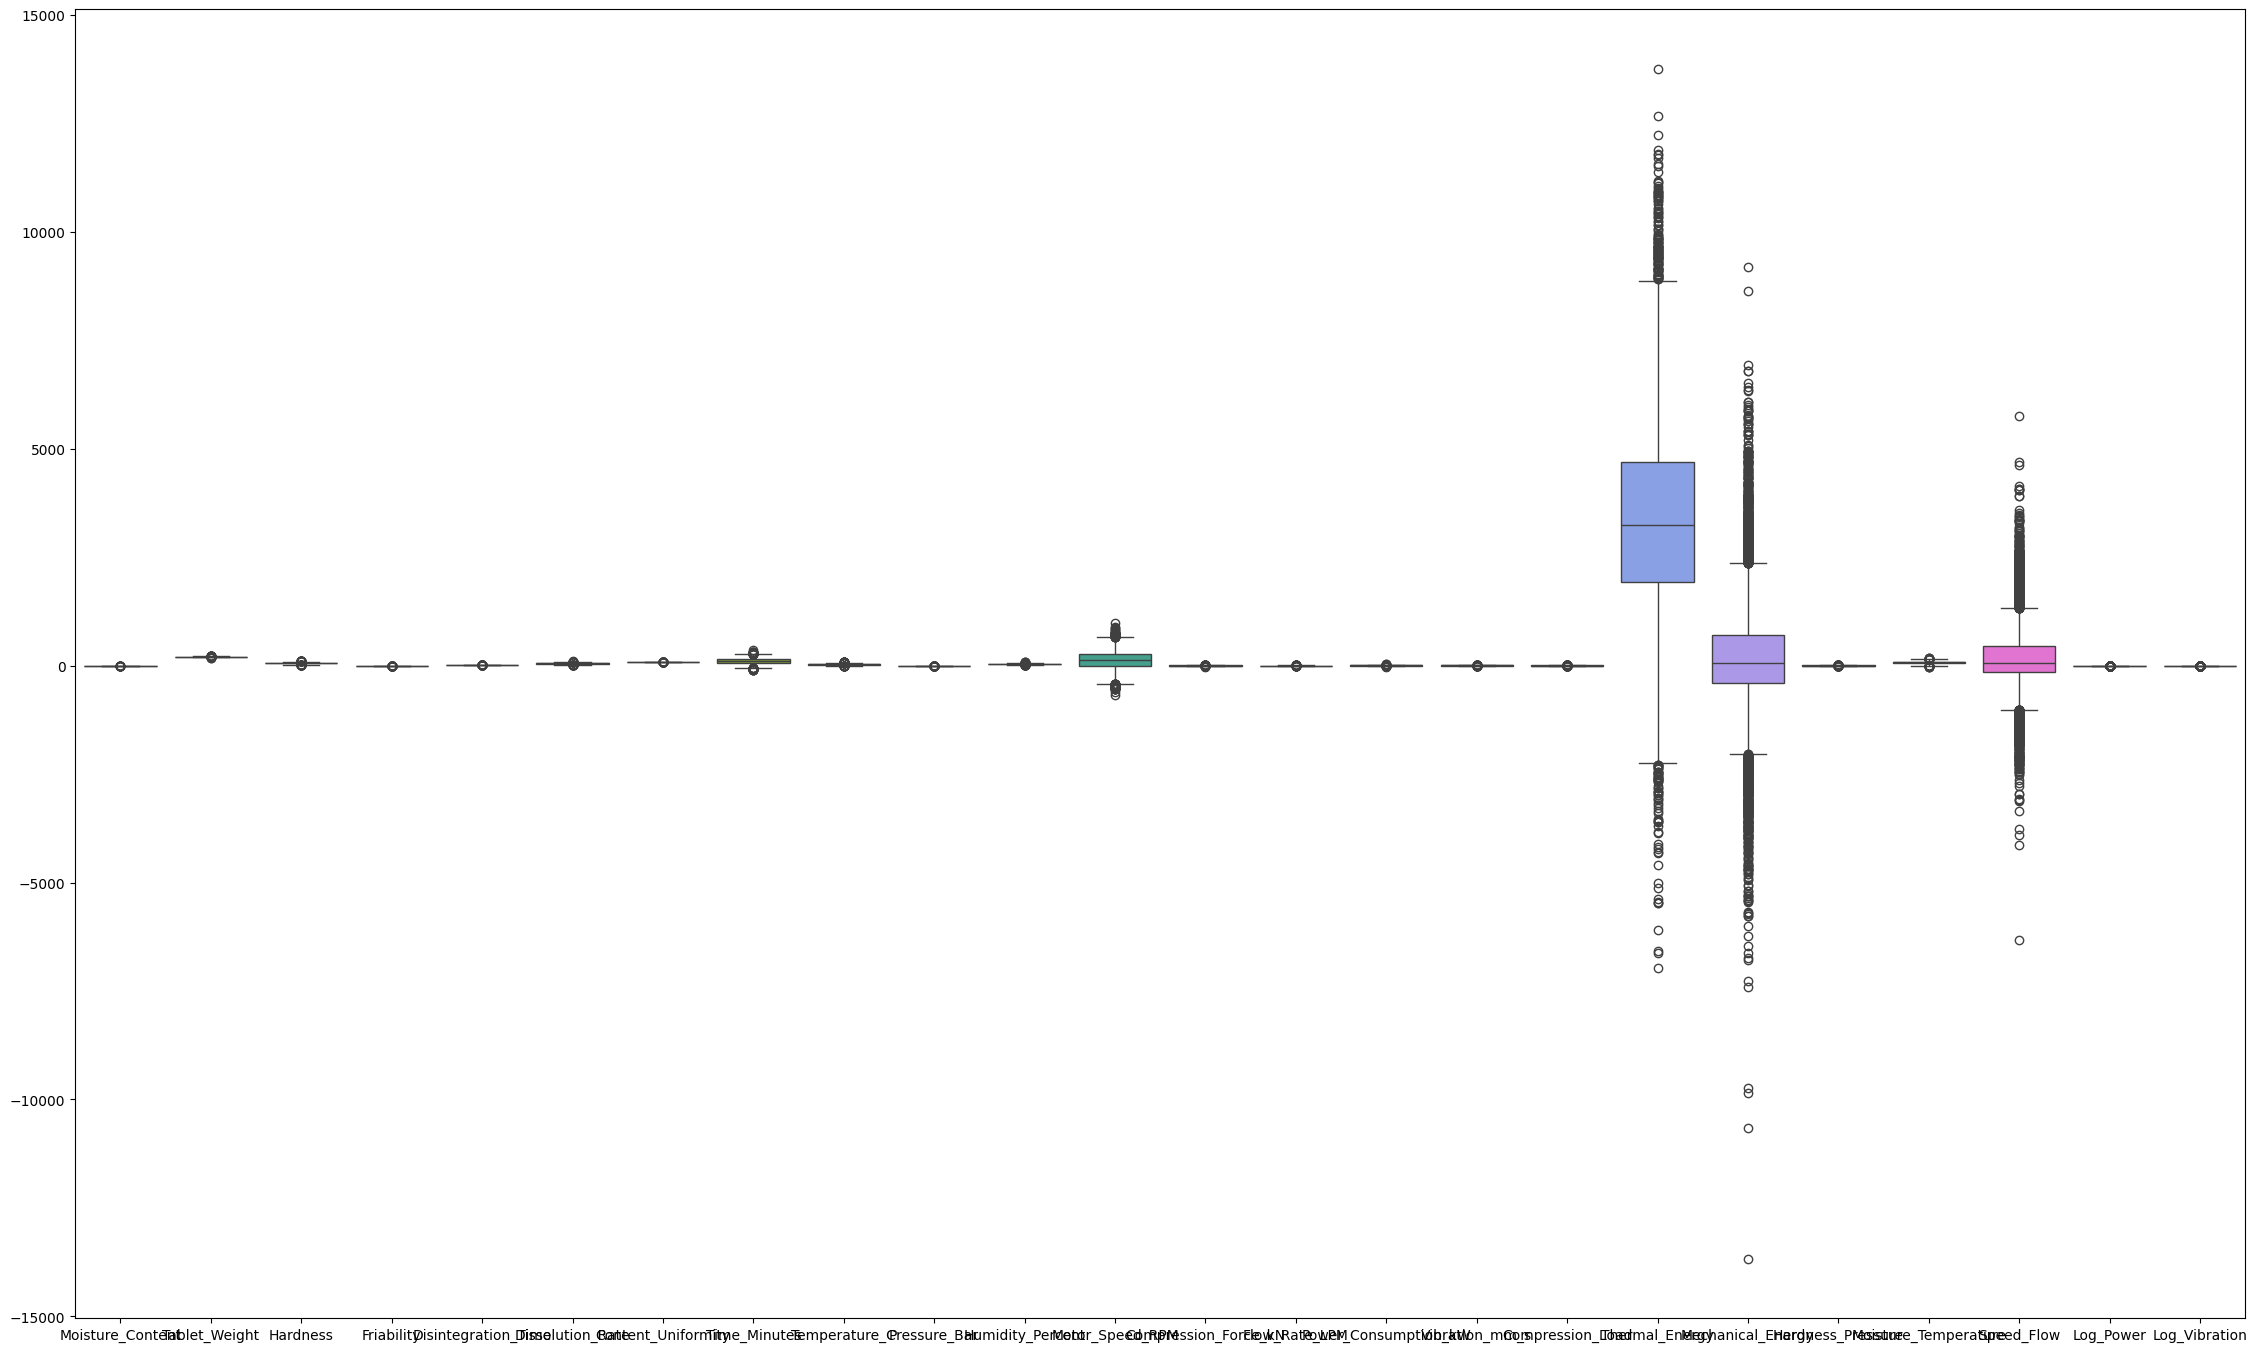

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(28,17))
sns.boxplot(augmented_data)

In [127]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [128]:
X_train.shape

(8000, 18)

In [129]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [130]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

models = {
    "RandomForest": MultiOutputRegressor(RandomForestRegressor(random_state=42)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(
        random_state=42,
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8)),
    "GradientBoosting": MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
    "SVR": MultiOutputRegressor(SVR())
}

In [131]:
param_grids = {

"RandomForest": {
    "estimator__n_estimators":[200,400,600],
    "estimator__max_depth":[8,12,16],
    "estimator__min_samples_split":[2,5,10],
    "estimator__min_samples_leaf":[1,2,4]
},

"XGBoost": {
    "estimator__n_estimators":[400,600,800],
    "estimator__max_depth":[4,6,8],
    "estimator__learning_rate":[0.03,0.05,0.07],
    "estimator__subsample":[0.8,0.9],
    "estimator__colsample_bytree":[0.7,0.8,0.9],
    "estimator__gamma":[0,0.1,0.2],
    "estimator__reg_lambda":[1,2]
},

"GradientBoosting": {
    "estimator__n_estimators":[200,400,600],
    "estimator__learning_rate":[0.01,0.05,0.1],
    "estimator__max_depth":[3,5,7]
},

"SVR": {
    "estimator__kernel":["rbf"],
    "estimator__C":[10,50,100],
    "estimator__epsilon":[0.01,0.1,0.2]
}
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

results = []

for name, model in models.items():

    search = RandomizedSearchCV(
        model,
        param_grids[name],
        n_iter=25,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    pred = best_model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

In [ ]:
results_df = pd.DataFrame(results)

print(results_df.sort_values("R2", ascending=False))

              Model        R2       MAE      RMSE
1           XGBoost  0.808667  0.524624  0.771122
2  GradientBoosting  0.808114  0.517562  0.744897
0      RandomForest  0.805472  0.586089  0.892877
3               SVR  0.747313  1.588121  3.127890


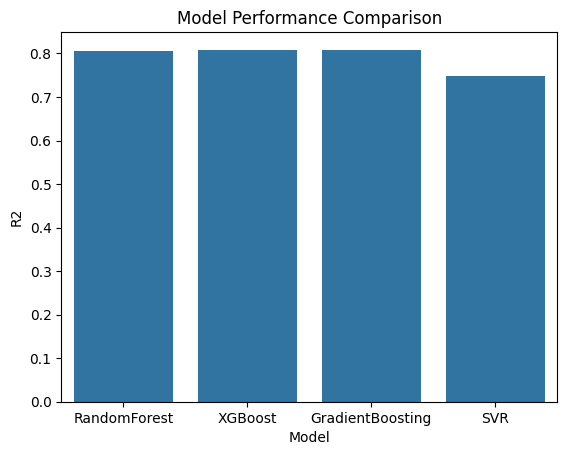

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="R2", data=results_df)

plt.title("Model Performance Comparison")
plt.show()

In [ ]:
augmented_data.corr(numeric_only=True)

,Moisture_Content,Tablet_Weight,Hardness,Friability,Disintegration_Time,Dissolution_Rate,Content_Uniformity,Time_Minutes,Temperature_C,Pressure_Bar,Humidity_Percent,Motor_Speed_RPM,Compression_Force_kN,Flow_Rate_LPM,Power_Consumption_kW,Vibration_mm_s,Compression_Load,Thermal_Energy,Moisture_Temp
Moisture_Content,1.000000,-0.010479,0.006690,-0.002446,0.008724,-0.010068,-0.007058,-0.007195,-0.011002,0.034127,0.006194,0.007512,0.002214,-0.016426,-0.000059,0.003905,0.003665,-0.014148,-0.011002
Tablet_Weight,-0.010479,1.000000,-0.176362,0.197153,-0.613533,0.503066,0.088103,-0.416336,0.889161,-0.290152,0.167515,0.483802,-0.391771,0.837559,-0.201691,-0.280674,-0.412266,0.157918,0.889161
Hardness,0.006690,-0.176362,1.000000,-0.905474,0.037145,-0.919137,0.240395,0.118585,-0.247460,-0.035879,-0.499066,0.230882,0.899727,-0.346330,0.898099,0.977187,0.887431,-0.036684,-0.247460
Friability,-0.002446,0.197153,-0.905474,1.000000,-0.079232,0.856155,-0.426865,-0.245645,0.283553,0.139038,0.809465,-0.170090,-0.833491,0.331367,-0.824148,-0.892538,-0.814398,-0.064536,0.283553
Disintegration_Time,0.008724,-0.613533,0.037145,-0.079232,1.000000,-0.334930,-0.096616,0.291117,-0.753725,0.133486,-0.116300,-0.010805,0.041531,-0.707991,-0.079776,0.040170,0.054101,-0.194000,-0.753725
Dissolution_Rate,-0.010068,0.503066,-0.919137,0.856155,-0.334930,1.000000,-0.171891,-0.269421,0.605803,-0.046377,0.509398,-0.133492,-0.862098,0.664887,-0.792012,-0.914888,-0.857695,0.117383,0.605803
Content_Uniformity,-0.007058,0.088103,0.240395,-0.426865,-0.096616,-0.171891,1.000000,0.134160,0.059699,-0.216504,-0.557697,0.018167,0.234485,0.092994,0.262918,0.240693,0.216780,0.175400,0.059699
Time_Minutes,-0.007195,-0.416336,0.118585,-0.245645,0.291117,-0.269421,0.134160,1.000000,-0.427532,0.019976,-0.352639,-0.215126,0.215337,-0.349559,0.133357,0.165679,0.213492,0.710219,-0.427532
Temperature_C,-0.011002,0.889161,-0.247460,0.283553,-0.753725,0.605803,0.059699,-0.427532,1.000000,-0.187611,0.249689,0.137638,-0.309582,0.945513,-0.139104,-0.283274,-0.323440,0.216738,1.000000
Pressure_Bar,0.034127,-0.290152,-0.035879,0.139038,0.133486,-0.046377,-0.216504,0.019976,-0.187611,1.000000,0.244189,-0.083147,-0.005218,-0.299055,-0.052923,-0.012757,0.069624,-0.101236,-0.187611


In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14,10))

# corr_matrix = augmented_data.corr(numeric_only=True)

# sns.heatmap(
#     corr_matrix,
#     cmap="coolwarm",
#     annot=True,
#     fmt=".2f",
#     linewidths=0.5
# )

# plt.title("Feature Correlation Heatmap")
# plt.show()